In [451]:
import math
import random
import matplotlib.pyplot as plt

In [452]:
def parse_fleet(file):
    with open(file,"r") as f:
        lines = [line.strip() for line in f if line.strip()]
    i=0
    while i<len(lines):
        parts=lines[i].split()
        if "cvrp" in file:
            if len(parts)==1:
                vehcile_capacity=int(parts[0])
                coordinates=lines[i+1].split()
                x_coordinate=float(coordinates[0])
                y_coordinate=float(coordinates[1])
                customers=[]
                for j in range(i+2,len(lines)):
                    each_line=lines[j].split()
                    customers.append({
                        "id": j-1,
                        "x_coordinate":float(each_line[0]),
                        "y_coordinate":float(each_line[1]),
                        "demand":int(each_line[2])
                    })
                return {
                    "vehicle_capacity":vehcile_capacity,
                    "depot_coordinates":(x_coordinate,y_coordinate),
                    "customers":customers
                }
        if "vrptw" in file:
          if len(parts)==2:
                number_of_vehicles=int(parts[0])
                vehcile_capacity=int(parts[1])
                coordinates=lines[i+1].split()
                x_coordinate=float(coordinates[0])
                y_coordinate=float(coordinates[1])
                customers=[]
                for j in range(i+2,len(lines)):
                    each_line=lines[j].split()
                    customers.append({
                        "id": j-2,
                        "x_coordinate":float(each_line[0]),
                        "y_coordinate":float(each_line[1]),
                        "demand":int(each_line[2]),
                        "time_window_opening":float(each_line[3]),
                        "time_window_closing":float(each_line[4]),
                        "service_time": float(each_line[5])
                    })
                return {
                    "number_of_vehicles": number_of_vehicles,
                    "vehicle_capacity":vehcile_capacity,
                    "depot_coordinates":(x_coordinate,y_coordinate),
                    "customers":customers
                }
                
        i+=1
    return None
print(parse_fleet("cvrp.txt"))
        

{'vehicle_capacity': 160, 'depot_coordinates': (30.0, 40.0), 'customers': [{'id': 1, 'x_coordinate': 37.0, 'y_coordinate': 52.0, 'demand': 7}, {'id': 2, 'x_coordinate': 49.0, 'y_coordinate': 49.0, 'demand': 30}, {'id': 3, 'x_coordinate': 52.0, 'y_coordinate': 64.0, 'demand': 16}, {'id': 4, 'x_coordinate': 20.0, 'y_coordinate': 26.0, 'demand': 9}, {'id': 5, 'x_coordinate': 40.0, 'y_coordinate': 30.0, 'demand': 21}, {'id': 6, 'x_coordinate': 21.0, 'y_coordinate': 47.0, 'demand': 15}, {'id': 7, 'x_coordinate': 17.0, 'y_coordinate': 63.0, 'demand': 19}, {'id': 8, 'x_coordinate': 31.0, 'y_coordinate': 62.0, 'demand': 23}, {'id': 9, 'x_coordinate': 52.0, 'y_coordinate': 33.0, 'demand': 11}, {'id': 10, 'x_coordinate': 51.0, 'y_coordinate': 21.0, 'demand': 5}, {'id': 11, 'x_coordinate': 42.0, 'y_coordinate': 41.0, 'demand': 19}, {'id': 12, 'x_coordinate': 31.0, 'y_coordinate': 32.0, 'demand': 29}, {'id': 13, 'x_coordinate': 5.0, 'y_coordinate': 25.0, 'demand': 23}, {'id': 14, 'x_coordinate': 1

# GRASP


In [ ]:

def euclidean_distance(x1, y1, x2, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def route_distance(routes, customer_dict, depot_coordinates):
    """Calculates total distance including return to depot for each route."""
    dist = 0.0
    depot_x, depot_y = depot_coordinates
    for route in routes:
        if not route:
            continue
        curr_x, curr_y = depot_x, depot_y
        for c_id in route:
            c = customer_dict[c_id]
            dist += euclidean_distance(curr_x, curr_y, c['x_coordinate'], c['y_coordinate'])
            curr_x, curr_y = c['x_coordinate'], c['y_coordinate']
        # Add return to depot for this specific route
        dist += euclidean_distance(curr_x, curr_y, depot_x, depot_y)
    return dist

def local_search_cvrp(routes, customers_list, depot_coords, capacity): 
    customers_dict = {c['id']: c for c in customers_list}
    best_routes = [r.copy() for r in routes]
    best_cost = route_distance(best_routes, customers_dict, depot_coords)
    
    improved = True
    while improved:
        improved = False
        for i in range(len(best_routes)):
            for idx, c_id in enumerate(best_routes[i]):
                for j in range(len(best_routes)):
                    for pos in range(len(best_routes[j]) + 1):
                        if i == j and (pos == idx or pos == idx + 1):
                            continue
                        
                        new_routes = [route.copy() for route in best_routes]
                        new_routes[i].pop(idx)
                        new_routes[j].insert(pos, c_id)
                        
                        # Capacity check
                        if sum(customers_dict[cid]['demand'] for cid in new_routes[j]) <= capacity:
                            new_cost = route_distance(new_routes, customers_dict, depot_coords)
                            if new_cost < best_cost:
                                best_routes, best_cost = new_routes, new_cost
                                improved = True
                                break
                    if improved: break
                if improved: break
            if improved: break
    return best_routes, best_cost

def build_solution_cvrp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, alpha):
    not_visited = customers.copy() 
    routes = []
    depot_x, depot_y = depot_coordinates
    
    for _ in range(number_of_vehicles):
        route = []
        rem_cap = vehicle_capacity
        while not_visited:
            if not route:
                curr_x, curr_y = depot_x, depot_y
            else:
                # FIX: Access using ['id'] and ['x_coordinate']
                last_c_id = route[-1]
                last_c = next(c for c in customers if c['id'] == last_c_id)
                curr_x, curr_y = last_c['x_coordinate'], last_c['y_coordinate']
            
            # FIX: Access using ['id'], ['x_coordinate'], ['y_coordinate']
            costs = {c['id']: euclidean_distance(curr_x, curr_y, c['x_coordinate'], c['y_coordinate']) 
                     for c in not_visited}
            
            min_c, max_c = min(costs.values()), max(costs.values())
            threshold = min_c + alpha * (max_c - min_c)
            
            # FIX: Access using ['demand']
            rcl = [c for c in not_visited if costs[c['id']] <= threshold and c['demand'] <= rem_cap]
            
            if not rcl: break 
            
            chosen = random.choice(rcl)
            route.append(chosen['id'])
            rem_cap -= chosen['demand']
            not_visited.remove(chosen)
            
        routes.append(route)
    return routes if not not_visited else None

def grasp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, alpha, max_iterations):
    best_cost = float("inf")
    best_routes = None
    
    for i in range(max_iterations):
        routes = None
        while routes is None:
            routes = build_solution_cvrp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, alpha)
        
        routes, cost = local_search_cvrp(routes, customers, depot_coordinates, vehicle_capacity)
        if cost < best_cost:
            best_routes = routes
            best_cost = cost

    return best_routes, best_cost

In [ ]:
def initialize_distance_matrix(data):
    points = [data['depot_coordinates']] + [(c['x_coordinate'], c['y_coordinate']) for c in data['customers']]
    num_of_points=len(points)
    matrix = [[0.0 for _ in range(num_of_points)] for _ in range(num_of_points)]
    for i in range(num_of_points):
        for j in range(num_of_points):
            x1,y1=points[i]
            x2,y2=points[j]
            matrix[i][j] = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return matrix
def get_demand(data):
    return [0] + [c['demand'] for c in data['customers']]
def initialize_pheromone_matrix(distance_matrix):
    m=len(distance_matrix)
    n=len(distance_matrix[0])
    pheromone_matrix = [[0.0 for _ in range(m)] for _ in range(n)]
    for i in range(m):
        for j in range(n):
            pheromone_matrix[i][j]=0.0001
    return pheromone_matrix
def initialize_visibility_matrix(distance_matrix):
    m=len(distance_matrix)
    n=len(distance_matrix[0])
    visibility_matrix = [[0.0 for _ in range(m)] for _ in range(n)]
    for i in range(m):
        for j in range(n):
            if i==j or distance_matrix[i][j]==0:
                visibility_matrix[i][j]=0
            else:
                visibility_matrix[i][j]=1.0/distance_matrix[i][j]
    return visibility_matrix
def probabilistic_traversal(distance_matrix,demand,max_capacity,Alpha,Beta,pheromone_matrix,visibility_matrix):
    pointer=0 #Depot
    length=len(distance_matrix)
    visited_status=[False for x in range(length)]
    visited_status[0]=True # Because that is the depot from where we start
    visited_node=[0]
    current_load=0
    #We iterate through every unvisited node
    while False in visited_status:
        feasible_indices=[]
        feasible_probabilities=[]
        current_node=distance_matrix[pointer]
        for j in range(length):
            if demand[j]+current_load<=max_capacity:
                if visited_status[j]==False:
                    #If the node wasn't visited and it sufices our constraint, this where we compute the attractiveness of a potential future node
                    thau = pheromone_matrix[pointer][j] #pheromone level
                    eta = visibility_matrix[pointer][j] #heuristic, short distance
                    prob_numerator = (thau ** Alpha) * (eta ** Beta) #Alpha and Beta have the purpose of deciding what is more important, putting more accent on pheromone levels or the heuristic who is more short term 
                    feasible_indices.append(j)
                    feasible_probabilities.append(prob_numerator)
        if feasible_indices:
            total=sum(feasible_probabilities)
            if total==0:#Even in the worst case, if all levels are close to 0 we still have to move somewhere, thus we pick a random suitable candidate
                selected_index=random.choice(feasible_indices)
            else:# A wheel of fortune is happening here. Meaning that we don't pick the customer with the highest probability, we just give him a bigger slice on the wheel
                norm_probabilities = [p / total for p in feasible_probabilities]
                selected_index = random.choices(feasible_indices, weights=norm_probabilities, k=1)[0] 
            visited_status[selected_index]=True
            current_load+=demand[selected_index]
            pointer=selected_index
            visited_node.append(pointer)
        else:
            if pointer!=0:
                pointer=0
                visited_node.append(pointer)
                current_load=0
            else:
                break
    if visited_node[-1]!=0:#We go back to depot
        visited_node.append(0)
    return visited_node

def calculate_distance(distance_matrix, visited_node):
    total=0
    for i in range(len(visited_node)-1):
        from_node=visited_node[i]
        to_node=visited_node[i+1]
        total+=distance_matrix[from_node][to_node]
    return total
                    

                

In [ ]:
def solve_basic_ACO():
    filename = "cvrp.txt"
    data = parse_fleet(filename)
    if not data:
        print("Failed to parse file.")
        return

    distance_matrix = initialize_distance_matrix(data)
    demands = get_demand(data)
    capacity = data['vehicle_capacity']
    
    length = len(distance_matrix)
    alpha=2.0         # Good if the goal is to explore more and embrace randomness
    beta = 3.5        # Priority for shorter distances
    rho = 0.1         # Evaporation rate
    num_ants = 10     # Ants per iteration
    iterations = 50   # Total generations

    pheromone_matrix = initialize_pheromone_matrix(distance_matrix)
    visibility_matrix = initialize_visibility_matrix(distance_matrix)
    
    # Champion Tracking
    best_global_dist = float('inf')
    best_global_tour = []

    print(f"Starting ACO for {length-1} customers...")

    # 4. Main Optimization Loop
    for it in range(iterations):
        all_tours = []
        all_distances = []

        for ant_id in range(num_ants):
            tour = probabilistic_traversal(distance_matrix, demands, capacity,alpha, beta, 
                                    pheromone_matrix, visibility_matrix)
            dist = calculate_distance(distance_matrix, tour)
            
            all_tours.append(tour)
            all_distances.append(dist)
            #print(f"  Ant {ant_id}: Dist {dist:.2f} | Route: {tour}")

        min_dist = min(all_distances)
        best_tour = all_tours[all_distances.index(min_dist)]

        if min_dist < best_global_dist:
            best_global_dist = min_dist
            best_global_tour = best_tour
            print(f"Iteration {it}: Found shorter route! Distance: {best_global_dist:.2f}")

        # Pheromone Evaporation (The memory fades)
        for i in range(length):
            for j in range(length):
                pheromone_matrix[i][j] *= (1 - rho)

        # We reward the best ant of THIS generation
        for k in range(len(best_tour) - 1):
            u, v = best_tour[k], best_tour[k+1]
            pheromone_matrix[u][v] += (1.0 / min_dist)

    print("-" * 30)
    print("OPTIMIZATION COMPLETE")
    print(f"Best Total Distance: {best_global_dist:.2f}")
    print(f"Full Tour Sequence: {best_global_tour}")
solve_basic_ACO()

Starting ACO for 50 customers...
Iteration 0: Found shorter route! Distance: 794.08
Iteration 1: Found shorter route! Distance: 783.46
Iteration 2: Found shorter route! Distance: 737.95
Iteration 12: Found shorter route! Distance: 736.34
Iteration 26: Found shorter route! Distance: 734.87
------------------------------
OPTIMIZATION COMPLETE
Best Total Distance: 734.87
Full Tour Sequence: [0, 12, 37, 5, 30, 34, 39, 10, 33, 45, 17, 0, 46, 6, 24, 43, 7, 23, 48, 22, 31, 28, 8, 26, 0, 14, 25, 13, 40, 41, 19, 42, 44, 15, 29, 0, 47, 18, 4, 2, 20, 35, 36, 0, 27, 11, 38, 49, 9, 50, 16, 21, 32, 1, 3, 0]


In [ ]:
def plot_aco_solution(tour, customers_list, depot_coordinates,final_distance, title="ACO CVRP Solution"):
    depot_x, depot_y = depot_coordinates
    cust_dict = {c['id']: c for c in customers_list}

    plt.figure(figsize=(12, 9))
    
    all_x = [c['x_coordinate'] for c in customers_list]
    all_y = [c['y_coordinate'] for c in customers_list]
    plt.scatter(all_x, all_y, c="lightgray", s=50, label="Customers", zorder=1)
    
    for c in customers_list:
        plt.text(c['x_coordinate'] + 0.5, c['y_coordinate'] + 0.5, str(c['id']), fontsize=9)

    plt.scatter([depot_x], [depot_y], c="red", s=200, marker="*", label="Depot", zorder=5)

    # Plot Routes
    # We split the tour into sub-routes whenever we see a '0'
    cmap = plt.get_cmap("tab20")
    current_route_x = [depot_x]
    current_route_y = [depot_y]
    route_count = 0

    for i in range(1, len(tour)):
        node_id = tour[i]
        if node_id == 0:
            # End of a sub-trip
            current_route_x.append(depot_x)
            current_route_y.append(depot_y)
            
            plt.plot(current_route_x, current_route_y, color=cmap(route_count % 20), 
                     linewidth=2, marker='o', markersize=4, alpha=0.7)
            
            current_route_x = [depot_x]
            current_route_y = [depot_y]
            route_count += 1
        else:
            c = cust_dict[node_id]
            current_route_x.append(c['x_coordinate'])
            current_route_y.append(c['y_coordinate'])

    plt.title(f"{title}\nTotal Distance: {final_distance:.2f}")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
def plot_grasp_baseline(routes, customers_list, depot_coordinates, baseline_dist):
    depot_x, depot_y = depot_coordinates
    cust_dict = {c['id']: c for c in customers_list}
    plt.figure(figsize=(10, 7))
    
    # Plot Depot and Customers
    plt.scatter([depot_x], [depot_y], c="red", s=200, marker="*", label="Depot", zorder=5)
    all_x = [c['x_coordinate'] for c in customers_list]
    all_y = [c['y_coordinate'] for c in customers_list]
    plt.scatter(all_x, all_y, c="gray", s=30, alpha=0.5)

    cmap = plt.get_cmap("tab20")
    for i, route in enumerate(routes):
        if not route: continue
        color = cmap(i % 20)
        curr_route_x = [depot_x] + [cust_dict[cid]['x_coordinate'] for cid in route] + [depot_x]
        curr_route_y = [depot_y] + [cust_dict[cid]['y_coordinate'] for cid in route] + [depot_y]
        plt.plot(curr_route_x, curr_route_y, color=color, linewidth=1.5, alpha=0.6, linestyle='--')

    plt.title(f"GRASP Baseline Routes\nTotal Distance: {baseline_dist:.2f}")
    plt.show()

def plot_convergence(history, baseline_dist):
    plt.figure(figsize=(10, 5))
    plt.plot(history, label="ACO Global Best", color="blue", linewidth=2)
    plt.axhline(y=baseline_dist, color='red', linestyle='--', label="GRASP Baseline")
    plt.title("ACO Convergence vs. GRASP Baseline")
    plt.xlabel("Iteration")
    plt.ylabel("Distance")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Running GRASP to find initial baseline...
GRASP Baseline Found: 597.68
Starting ACO for 50 customers...
Iteration   0: Iteration Best: 1425.49 | Global Best: inf | Gap: +nan%
>>> NEW RECORD at Iteration 0: 1425.49
>>> NEW RECORD at Iteration 1: 666.43
>>> NEW RECORD at Iteration 5: 654.32
>>> NEW RECORD at Iteration 6: 641.04
>>> NEW RECORD at Iteration 7: 635.92
Iteration  10: Iteration Best: 640.32 | Global Best: 635.92 | Gap: +0.69%
>>> NEW RECORD at Iteration 13: 635.92
>>> NEW RECORD at Iteration 14: 622.14
Iteration  20: Iteration Best: 635.92 | Global Best: 622.14 | Gap: +2.22%
>>> NEW RECORD at Iteration 24: 609.17
>>> NEW RECORD at Iteration 26: 605.62
Iteration  30: Iteration Best: 633.76 | Global Best: 605.62 | Gap: +4.65%
>>> NEW RECORD at Iteration 38: 605.62
Iteration  40: Iteration Best: 622.14 | Global Best: 605.62 | Gap: +2.73%
>>> NEW RECORD at Iteration 41: 605.07
Iteration  50: Iteration Best: 654.80 | Global Best: 605.07 | Gap: +8.22%
Iteration  60: Iteration Best:

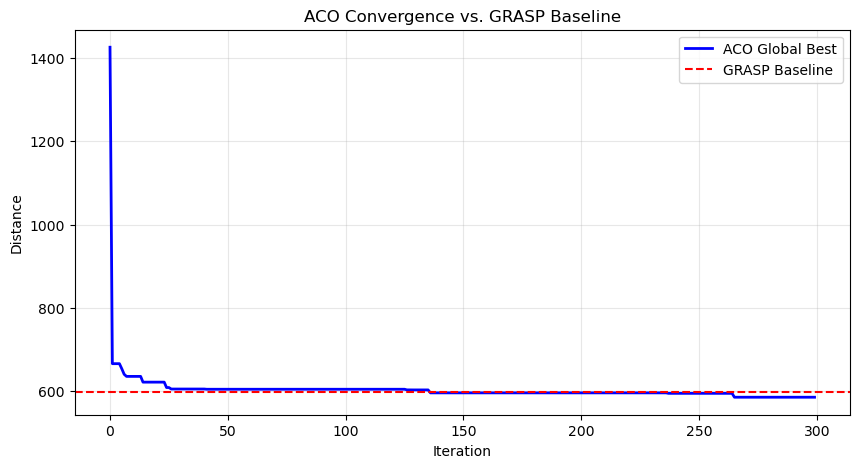

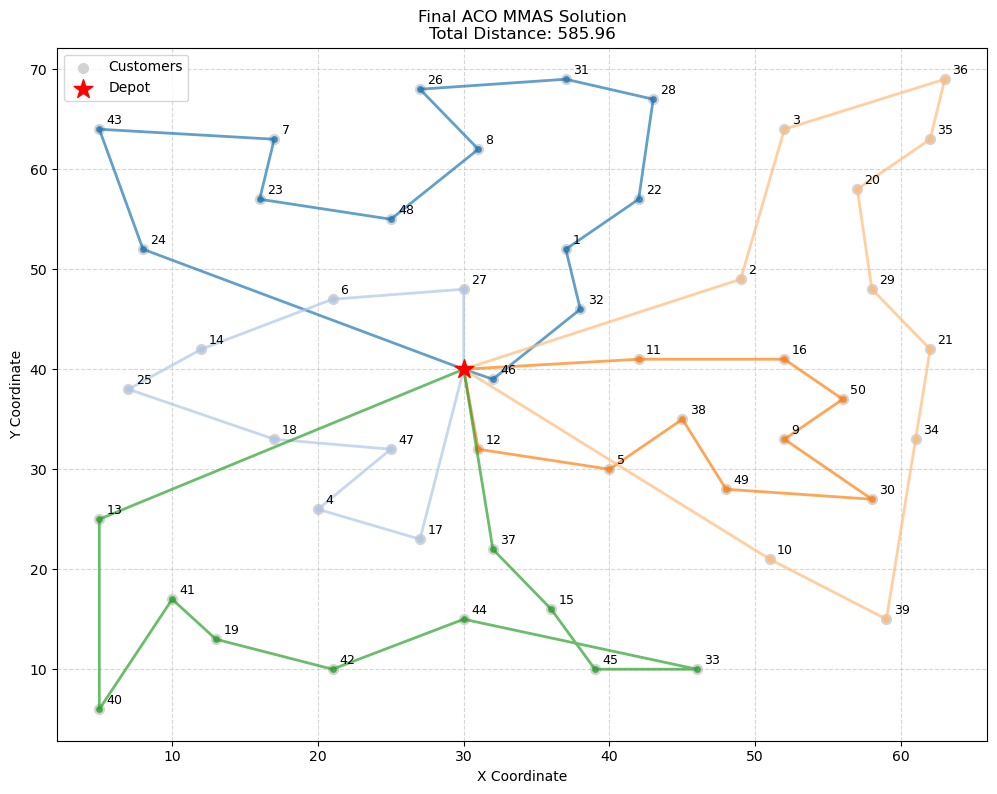

In [ ]:
def solve_max_min_ACO():
    filename = "cvrp.txt"
    data = parse_fleet(filename)

    distance_matrix = initialize_distance_matrix(data)
    demands = get_demand(data)
    capacity = data['vehicle_capacity']
    depot_coords = data['depot_coordinates']
    length = len(distance_matrix)
    
    # Parameters
    alpha = 2.0  # Good if the goal is to explore more and embrace randomness
    beta = 5.0   # Priority for shorter distances  
    rho = 0.05   # Evaporation rate     
    num_ants = 20    # Ants per iteration
    iterations = 300 # Total generations

    # GRASP BASELINE
    print("Running GRASP to find initial baseline...")
    baseline_routes, baseline_dist = grasp(
        number_of_vehicles=20, 
        vehicle_capacity=capacity, 
        depot_coordinates=depot_coords, 
        customers=data['customers'], 
        alpha=0.1, 
        max_iterations=10
    )
    
    best_global_dist_grasp=baseline_dist
    best_global_dist = float('inf')
    best_global_tour = [] 
    history = []
    
    print(f"GRASP Baseline Found: {best_global_dist_grasp:.2f}")

    # Set initial MMAS bounds
    tau_max = 1.0 / (rho * best_global_dist)
    tau_min = tau_max / 20.0
    
    pheromone_matrix = [[tau_max for _ in range(length)] for _ in range(length)]
    visibility_matrix = initialize_visibility_matrix(distance_matrix)

    print(f"Starting ACO for {length-1} customers...")

    # MAIN OPTIMIZATION LOOP
    for it in range(iterations):
        all_tours = []
        all_distances = []
        
        for ant_id in range(num_ants):
            tour = probabilistic_traversal(distance_matrix, demands, capacity, alpha, beta, 
                                           pheromone_matrix, visibility_matrix)
            dist = calculate_distance(distance_matrix, tour)
            all_tours.append(tour)
            all_distances.append(dist)

        min_dist_this_gen = min(all_distances)
        best_tour_this_gen = all_tours[all_distances.index(min_dist_this_gen)]

        # Progress reporting
        if it % 10 == 0:
            gap = ((min_dist_this_gen - best_global_dist) / best_global_dist) * 100
            print(f"Iteration {it:3}: Iteration Best: {min_dist_this_gen:.2f} | "
                  f"Global Best: {best_global_dist:.2f} | Gap: {gap:+.2f}%")

        if min_dist_this_gen < best_global_dist:
            best_global_dist = min_dist_this_gen
            best_global_tour = best_tour_this_gen
            print(f">>> NEW RECORD at Iteration {it}: {best_global_dist:.2f}")

        history.append(best_global_dist)

        # Pheromone Evaporation
        for i in range(length):
            for j in range(length):
                pheromone_matrix[i][j] *= (1 - rho)

        if best_global_tour:
            reward = 1.0 / best_global_dist
            for k in range(len(best_global_tour) - 1):
                u, v = best_global_tour[k], best_global_tour[k+1]
                pheromone_matrix[u][v] += reward
                pheromone_matrix[v][u] += reward
            
        tau_max = 1.0 / (rho * best_global_dist)
        tau_min = tau_max / 20.0
        for i in range(length):
            for j in range(length):
                pheromone_matrix[i][j] = max(tau_min, min(tau_max, pheromone_matrix[i][j]))

    print("-" * 30)
    print("OPTIMIZATION COMPLETE")
    
    plot_convergence(history, baseline_dist)
    
    if best_global_tour:
        plot_aco_solution(best_global_tour, data['customers'], depot_coords,best_global_dist, title="Final ACO MMAS Solution")
    else:
        print("ACO could not beat the GRASP baseline.")

solve_max_min_ACO()